# LV Occupancy Cache Builder

Pre-computes geometry + occupancy labels for the LV dataset.

---

### What a real SAX MRI segmentation looks like

A short-axis cardiac MRI is a stack of 2-D imaging planes, each at a fixed z.
A cardiologist draws **two closed contours** on each plane:

| Contour | Traces |
|---|---|
| **Endo** (tissue = 0) | Inner LV wall — blood pool boundary |
| **Epi** (tissue = 1) | Outer LV wall — myocardium boundary |

Each contour is a single clean 2-D ring at exactly that z — no thickness.

The cache simulates these by **intersecting the 3-D mesh with a plane**
(`slice_mesh_at_z`), giving exactly 2 rings per slice by construction.

---

### Cache arrays

| Array | Shape | Description |
|---|---|---|
| `contour` | (N, 4) | xyz + tissue (0=endo, 1=epi) |
| `slice_ids` | (N,) | slice index [0…n_slices-1] |
| `slice_z` | (n_slices,) | normalised z-centre of each slice |
| `slice_z_mask` | (n_slices,) bool | valid slices — attention mask |
| `query` | (2048, 3) | occupancy supervision points |
| `endo_occ` | (2048,) | 1 = inside endocardium |
| `epi_occ` | (2048,) | 1 = inside epicardium |

### Model pipeline
```
contour + slice_ids  → SlicePointNetEncoder    (per-slice MLP + tissue-aware max-pool)
slice embeddings     → CrossSliceTransformer   (self-attention + global pool)
slice_z + mask       → SliceQueryConditioner   (z-interpolated local conditioning)
query xyz            → FourierPE               (Fourier positional encoding)
PE + conditioning    → SliceCondINRDecoder      (FiLM MLP → endo_logit, epi_logit)
```


In [88]:
!rm -rf /kaggle/working/occupancy_cache

## 1. Install dependencies

In [89]:
%pip install -q vtk tqdm scipy scikit-learn trimesh

Note: you may need to restart the kernel to use updated packages.


## 2. Imports

In [90]:
import os, json, warnings
import numpy as np
from pathlib import Path
from tqdm.notebook import tqdm
from sklearn.model_selection import train_test_split
import vtk

warnings.filterwarnings('ignore')
np.random.seed(42)
print('OK')


OK


## 3. Configuration

In [91]:
TRIAL_MODE = False   # set False for full run

CFG = dict(
    mesh_dir        = '/kaggle/input/datasets/andrefce/dataset-tese-meshes/generated_meshes(2)/generated_meshes',
    cache_dir       = '/kaggle/working/occupancy_cache',

    # SAX protocol matching real clinical acquisition
    n_slices        = 10,
    slice_space     = 10.0,    # mm between imaging planes
    pts_per_ring    = 60,      # points kept per contour after subsampling

    # Occupancy sampling
    n_query         = 2048,
    surface_std     = 2.0,

    seed            = 42,
)

os.makedirs(CFG['cache_dir'], exist_ok=True)
print('TRIAL' if TRIAL_MODE else 'FULL')

FULL


## 4. Load metadata

In [92]:
def load_vtk_mesh(path):
    reader = vtk.vtkPolyDataReader()
    reader.SetFileName(str(path))
    reader.Update()
    poly = reader.GetOutput()
    tri  = vtk.vtkTriangleFilter()
    tri.SetInputData(poly)
    tri.Update()
    poly = tri.GetOutput()
    pts  = poly.GetPoints()
    verts = np.array([pts.GetPoint(i) for i in range(pts.GetNumberOfPoints())],
                     dtype=np.float32)
    cells_vtk = poly.GetPolys()
    cells_vtk.InitTraversal()
    id_list = vtk.vtkIdList()
    faces = []
    while cells_vtk.GetNextCell(id_list):
        if id_list.GetNumberOfIds() == 3:
            faces.append([id_list.GetId(j) for j in range(3)])
    return verts, np.array(faces, dtype=np.int64)


with open(f'{CFG['mesh_dir']}/metadata.json') as f:
    raw_meta = json.load(f)
metadata = [m for m in raw_meta if m.get('accepted', True)]
if TRIAL_MODE:
    metadata = metadata[:2]
print(f'Meshes: {len(metadata)}')

all_idx = np.arange(len(metadata))
if len(metadata) <= 2:
    tr_idx  = np.array([0])
    val_idx = np.array([1]) if len(metadata) > 1 else np.array([0])
    te_idx  = np.array([], dtype=int)
else:
    tv, te_idx  = train_test_split(all_idx, test_size=0.1, random_state=CFG['seed'])
    tr_idx, val_idx = train_test_split(tv, test_size=0.2, random_state=CFG['seed'])

print(f'Train {len(tr_idx)} | Val {len(val_idx)} | Test {len(te_idx)}')
split = dict(tr=tr_idx.tolist(), val=val_idx.tolist(), te=te_idx.tolist())
with open(f'{CFG['cache_dir']}/split.json', 'w') as f:
    json.dump(split, f)
print('Split saved')


Meshes: 1300
Train 936 | Val 234 | Test 130
Split saved


## 5. Helper functions

In [93]:
# ═══════════════════════════════════════════════════════════════
# Split a single mesh into endo (inner) and epi (outer) surfaces
#
# The generated meshes already contain both surfaces as two
# connected components in one .vtk file.  We separate them by
# running VTK connectivity extraction, then assign:
#   inner surface (smaller mean radius from centroid) → endo
#   outer surface (larger mean radius from centroid)  → epi
# ═══════════════════════════════════════════════════════════════

def split_endo_epi(verts, faces):
    """Split a two-component mesh into (endo_verts, endo_faces, epi_verts, epi_faces).

    Works by finding which vertices belong to each connected component
    via a union-find on the face adjacency graph, then assigning the
    component with smaller mean radius = endo, larger = epi.
    """
    # Union-Find on vertices via face connectivity
    parent = list(range(len(verts)))

    def find(x):
        while parent[x] != x:
            parent[x] = parent[parent[x]]
            x = parent[x]
        return x

    def union(a, b):
        a, b = find(a), find(b)
        if a != b:
            parent[a] = b

    for f in faces:
        union(f[0], f[1])
        union(f[1], f[2])

    # Group faces by their component root
    from collections import defaultdict
    comp_faces = defaultdict(list)
    for f in faces:
        comp_faces[find(f[0])].append(f)

    if len(comp_faces) < 2:
        raise ValueError(f"Expected 2 components, found {len(comp_faces)}. "
                         f"Mesh may be a single surface — check your .vtk files.")

    # Take the two largest components
    sorted_comps = sorted(comp_faces.items(), key=lambda x: -len(x[1]))[:2]

    surfaces = []
    for root, flist in sorted_comps:
        f_arr  = np.array(flist, dtype=np.int64)
        v_idx  = np.unique(f_arr)
        remap  = {old: new for new, old in enumerate(v_idx)}
        v_arr  = verts[v_idx]
        f_re   = np.array([[remap[i] for i in row] for row in f_arr], dtype=np.int64)
        centroid = v_arr.mean(0)
        mean_r   = np.linalg.norm(v_arr - centroid, axis=1).mean()
        surfaces.append((mean_r, v_arr, f_re))

    surfaces.sort(key=lambda x: x[0])          # ascending radius
    _, endo_v, endo_f = surfaces[0]             # inner → endo
    _, epi_v,  epi_f  = surfaces[1]             # outer → epi
    return endo_v.astype(np.float32), endo_f, epi_v.astype(np.float32), epi_f


# ═══════════════════════════════════════════════════════════════
# True plane intersection (unchanged)
# ═══════════════════════════════════════════════════════════════

def slice_mesh_at_z(verts, faces, z, pts_per_ring=60):
    """Intersect triangle mesh with the plane z=const.
    Returns (N, 2) array sorted angularly, subsampled to pts_per_ring,
    or None if fewer than 3 crossing points are found.
    """
    crossings = []
    for ia, ib in [(0,1),(1,2),(2,0)]:
        za   = verts[faces[:, ia], 2]
        zb   = verts[faces[:, ib], 2]
        mask = (za - z) * (zb - z) < 0
        if mask.sum() == 0:
            continue
        t  = (z - za[mask]) / (zb[mask] - za[mask])
        pa = verts[faces[mask, ia], :2]
        pb = verts[faces[mask, ib], :2]
        crossings.append(pa + t[:, None] * (pb - pa))

    if not crossings:
        return None
    pts = np.vstack(crossings)
    if len(pts) < 2:
        return None

    c     = pts.mean(0)
    order = np.argsort(np.arctan2(pts[:,1]-c[1], pts[:,0]-c[0]))
    pts   = pts[order]

    if len(pts) > pts_per_ring:
        idx = np.round(np.linspace(0, len(pts)-1, pts_per_ring)).astype(int)
        pts = pts[idx]

    return pts.astype(np.float32)


# ═══════════════════════════════════════════════════════════════
# SAX contour extraction (unchanged)
# ═══════════════════════════════════════════════════════════════

def extract_sax_contours(endo_verts, endo_faces,
                          epi_verts,  epi_faces,
                          n_slices=10, space=10.0, pts_per_ring=60):
    all_v    = np.vstack([endo_verts, epi_verts])
    z_min, z_max = all_v[:,2].min(), all_v[:,2].max()
    z_span   = z_max - z_min
    fixed_span = space * (n_slices - 1)
    if fixed_span >= z_span * 0.95:
        # Fixed spacing would place apex/base slices outside the mesh.
        # Fall back to adaptive: distribute n_slices evenly across the
        # actual z-extent with a small inset margin (3% each side).
        margin = z_span * 0.05
        z_ctrs = np.linspace(z_min + margin, z_max - margin,
                             n_slices).astype(np.float32)
    else:
        start  = z_min + (z_span - fixed_span) / 2.0
        z_ctrs = (start + np.arange(n_slices) * space).astype(np.float32)

    all_xyz, all_tissue, all_sids = [], [], []
    valid_mask = np.zeros(n_slices, dtype=bool)

    for si, zc in enumerate(z_ctrs):
        has = False
        for label, vv, ff in [(0.0, endo_verts, endo_faces),
                               (1.0, epi_verts,  epi_faces)]:
            ring = slice_mesh_at_z(vv, ff, float(zc), pts_per_ring)
            if ring is None:
                continue
            z_col = np.full(len(ring), zc, dtype=np.float32)
            all_xyz.append(np.column_stack([ring, z_col]))
            all_tissue.append(np.full(len(ring), label, dtype=np.float32))
            all_sids.append(np.full(len(ring), si, dtype=np.int64))
            has = True
        if has:
            valid_mask[si] = True

    if not all_xyz:
        return (np.empty((0,3), np.float32), np.empty(0, np.float32),
                np.empty(0, np.int64), z_ctrs, valid_mask)

    return (np.vstack(all_xyz).astype(np.float32),
            np.concatenate(all_tissue),
            np.concatenate(all_sids),
            z_ctrs, valid_mask)


# ═══════════════════════════════════════════════════════════════
# Normalisation
# ═══════════════════════════════════════════════════════════════

def normalize_xyz(xyz, centroid=None, scale=None):
    out = xyz.copy().astype(np.float32)
    if centroid is None:
        cxy      = out[:,:2].mean(0)
        centroid = np.array([cxy[0], cxy[1], out[:,2].mean()], dtype=np.float32)
    if scale is None:
        scale = float(np.linalg.norm(out[:,:2]-centroid[:2], axis=1).mean().clip(min=1e-3))
    out -= centroid
    out /= scale
    return out, centroid, float(scale)


# ═══════════════════════════════════════════════════════════════
# Radial occupancy (unchanged)
# ═══════════════════════════════════════════════════════════════

def radial_occupancy(query, inner_verts, outer_verts):
    q_r     = np.linalg.norm(query, axis=1)
    q_unit  = query / q_r[:, None].clip(min=1e-8)

    in_r    = np.linalg.norm(inner_verts, axis=1)
    out_r   = np.linalg.norm(outer_verts, axis=1)
    in_unit = inner_verts / in_r[:, None].clip(min=1e-8)
    out_unit= outer_verts / out_r[:, None].clip(min=1e-8)

    inner_r_at_q = in_r [np.argmax(q_unit @ in_unit.T,  axis=1)]
    outer_r_at_q = out_r[np.argmax(q_unit @ out_unit.T, axis=1)]

    endo_occ = (q_r < inner_r_at_q).astype(np.float32)
    epi_occ  = (q_r < outer_r_at_q).astype(np.float32)
    epi_occ  = np.maximum(epi_occ, endo_occ)
    return endo_occ, epi_occ


print('Helper functions defined')


Helper functions defined


## 6. Core: 

In [94]:
def precompute_geometry(meta_row, global_idx, cfg):
    """Compute and cache one sample.

    1. Load mesh (VTK) — contains both endo and epi surfaces.
    2. Split into endo (inner) and epi (outer) via connectivity.
    3. True plane intersection → SAX contours (exactly 2 rings per slice).
    4. Normalise from endo centroid/scale.
    5. Sample 2048 query points (40% near endo, 40% near epi, 20% random).
    6. Label via radial_occupancy.
    """
    idx  = meta_row.get('saved_idx', 0)
    path = os.path.join(cfg['mesh_dir'], f'mesh_{int(idx):04d}.vtk')
    rng  = np.random.default_rng(global_idx)

    all_v, all_f = load_vtk_mesh(path)
    if len(all_f) == 0:
        raise ValueError(f'Empty mesh: {path}')

    endo_v, endo_f, epi_v, epi_f = split_endo_epi(all_v, all_f)

    xyz, tissue, sids, z_ctrs, valid = extract_sax_contours(
        endo_v, endo_f, epi_v, epi_f,
        cfg['n_slices'], cfg['slice_space'], cfg['pts_per_ring'])

    if len(xyz) == 0:
        raise ValueError(f'No valid slices found for mesh {idx}')

    _, centroid, scale = normalize_xyz(endo_v)
    xyz_n,   _, _ = normalize_xyz(xyz,    centroid, scale)
    endo_vn, _, _ = normalize_xyz(endo_v, centroid, scale)
    epi_vn,  _, _ = normalize_xyz(epi_v,  centroid, scale)
    z_ctrs_n = (z_ctrs - centroid[2]) / scale

    contour = np.column_stack([xyz_n, tissue]).astype(np.float32)

    n_q    = cfg['n_query']
    s_std  = cfg['surface_std'] / scale
    n_surf = int(n_q * 0.4)
    n_rand = n_q - 2 * n_surf

    e_pts = (endo_vn[rng.integers(0, len(endo_vn), n_surf)]
             + rng.normal(0, s_std, (n_surf, 3)).astype(np.float32))
    p_pts = (epi_vn [rng.integers(0, len(epi_vn),  n_surf)]
             + rng.normal(0, s_std, (n_surf, 3)).astype(np.float32))
    av    = np.vstack([endo_vn, epi_vn])
    lo, hi= av.min(0)-0.2, av.max(0)+0.2
    r_pts = rng.uniform(lo, hi, (n_rand, 3)).astype(np.float32)
    query = np.vstack([e_pts, p_pts, r_pts]).astype(np.float32)

    endo_occ, epi_occ = radial_occupancy(query, endo_vn, epi_vn)

    return dict(
        contour      = contour,
        slice_ids    = sids.astype(np.int64),
        slice_z      = z_ctrs_n.astype(np.float32),
        slice_z_mask = valid.astype(np.bool_),
        endo_vertices= endo_vn.astype(np.float32),
        endo_faces   = endo_f.astype(np.int32),
        epi_vertices = epi_vn.astype(np.float32),
        epi_faces    = epi_f.astype(np.int32),
        scale        = np.float32(scale),
        centroid     = centroid.astype(np.float32),
        query        = query.astype(np.float32),
        endo_occ     = endo_occ.astype(np.float32),
        epi_occ      = epi_occ.astype(np.float32),
    )


print('precompute_geometry defined')


precompute_geometry defined


## 7. Build the cache

In [95]:
cache_dir = Path(CFG['cache_dir'])
existing  = set(f.stem for f in cache_dir.glob('sample_*.npz'))
to_build  = [(i,m) for i,m in enumerate(metadata)
             if f'sample_{i:04d}' not in existing]
print(f'Cached: {len(existing)}  To build: {len(to_build)}')

errors = []
for gi, m in tqdm(to_build, desc='Building cache'):
    try:
        d = precompute_geometry(m, gi, CFG)
        np.savez_compressed(cache_dir/f'sample_{gi:04d}.npz', **d)
    except Exception as e:
        errors.append((gi, str(e)))
        print(f'  sample {gi}: {e}')

print(f'Done: {len(list(cache_dir.glob("sample_*.npz")))} files')
if errors: print(f'{len(errors)} errors: {errors}')


Cached: 0  To build: 1300


Building cache:   0%|          | 0/1300 [00:00<?, ?it/s]

Done: 1300 files


## 8. Verify

In [96]:
sample_files = sorted(cache_dir.glob('sample_*.npz'))
assert sample_files, 'No cache files!'

d = np.load(sample_files[0])
print(f'Sample: {sample_files[0].name}')
print(f'  contour      : {d["contour"].shape}    (N x 4: xyz + tissue)')
print(f'  slice_ids    : unique = {np.unique(d["slice_ids"])}')
print(f'  slice_z_mask : {d["slice_z_mask"].sum()}/{len(d["slice_z_mask"])} valid slices')
print(f'  endo_occ     : {d["endo_occ"].mean()*100:.1f}%  (expect 25-35%)')
print(f'  epi_occ      : {d["epi_occ"].mean()*100:.1f}%  (expect 55-70%)')

nv = ((d['endo_occ']==1)&(d['epi_occ']==0)).sum()
print(f'  nesting violations: {nv}  (expect 0)')
assert nv == 0

print('\nPer-slice ring check (endo + epi per slice):')
ctour = d['contour'];  sids = d['slice_ids']
for si in np.unique(sids):
    p = ctour[sids==si]
    print(f'  slice {si:2d}:  endo={int((p[:,3]==0).sum()):3d}  epi={int((p[:,3]==1).sum()):3d}')

print('\nVerification passed')


Sample: sample_0000.npz
  contour      : (1200, 4)    (N x 4: xyz + tissue)
  slice_ids    : unique = [0 1 2 3 4 5 6 7 8 9]
  slice_z_mask : 10/10 valid slices
  endo_occ     : 22.2%  (expect 25-35%)
  epi_occ      : 66.0%  (expect 55-70%)
  nesting violations: 0  (expect 0)

Per-slice ring check (endo + epi per slice):
  slice  0:  endo= 60  epi= 60
  slice  1:  endo= 60  epi= 60
  slice  2:  endo= 60  epi= 60
  slice  3:  endo= 60  epi= 60
  slice  4:  endo= 60  epi= 60
  slice  5:  endo= 60  epi= 60
  slice  6:  endo= 60  epi= 60
  slice  7:  endo= 60  epi= 60
  slice  8:  endo= 60  epi= 60
  slice  9:  endo= 60  epi= 60

Verification passed


## 9. Visualise

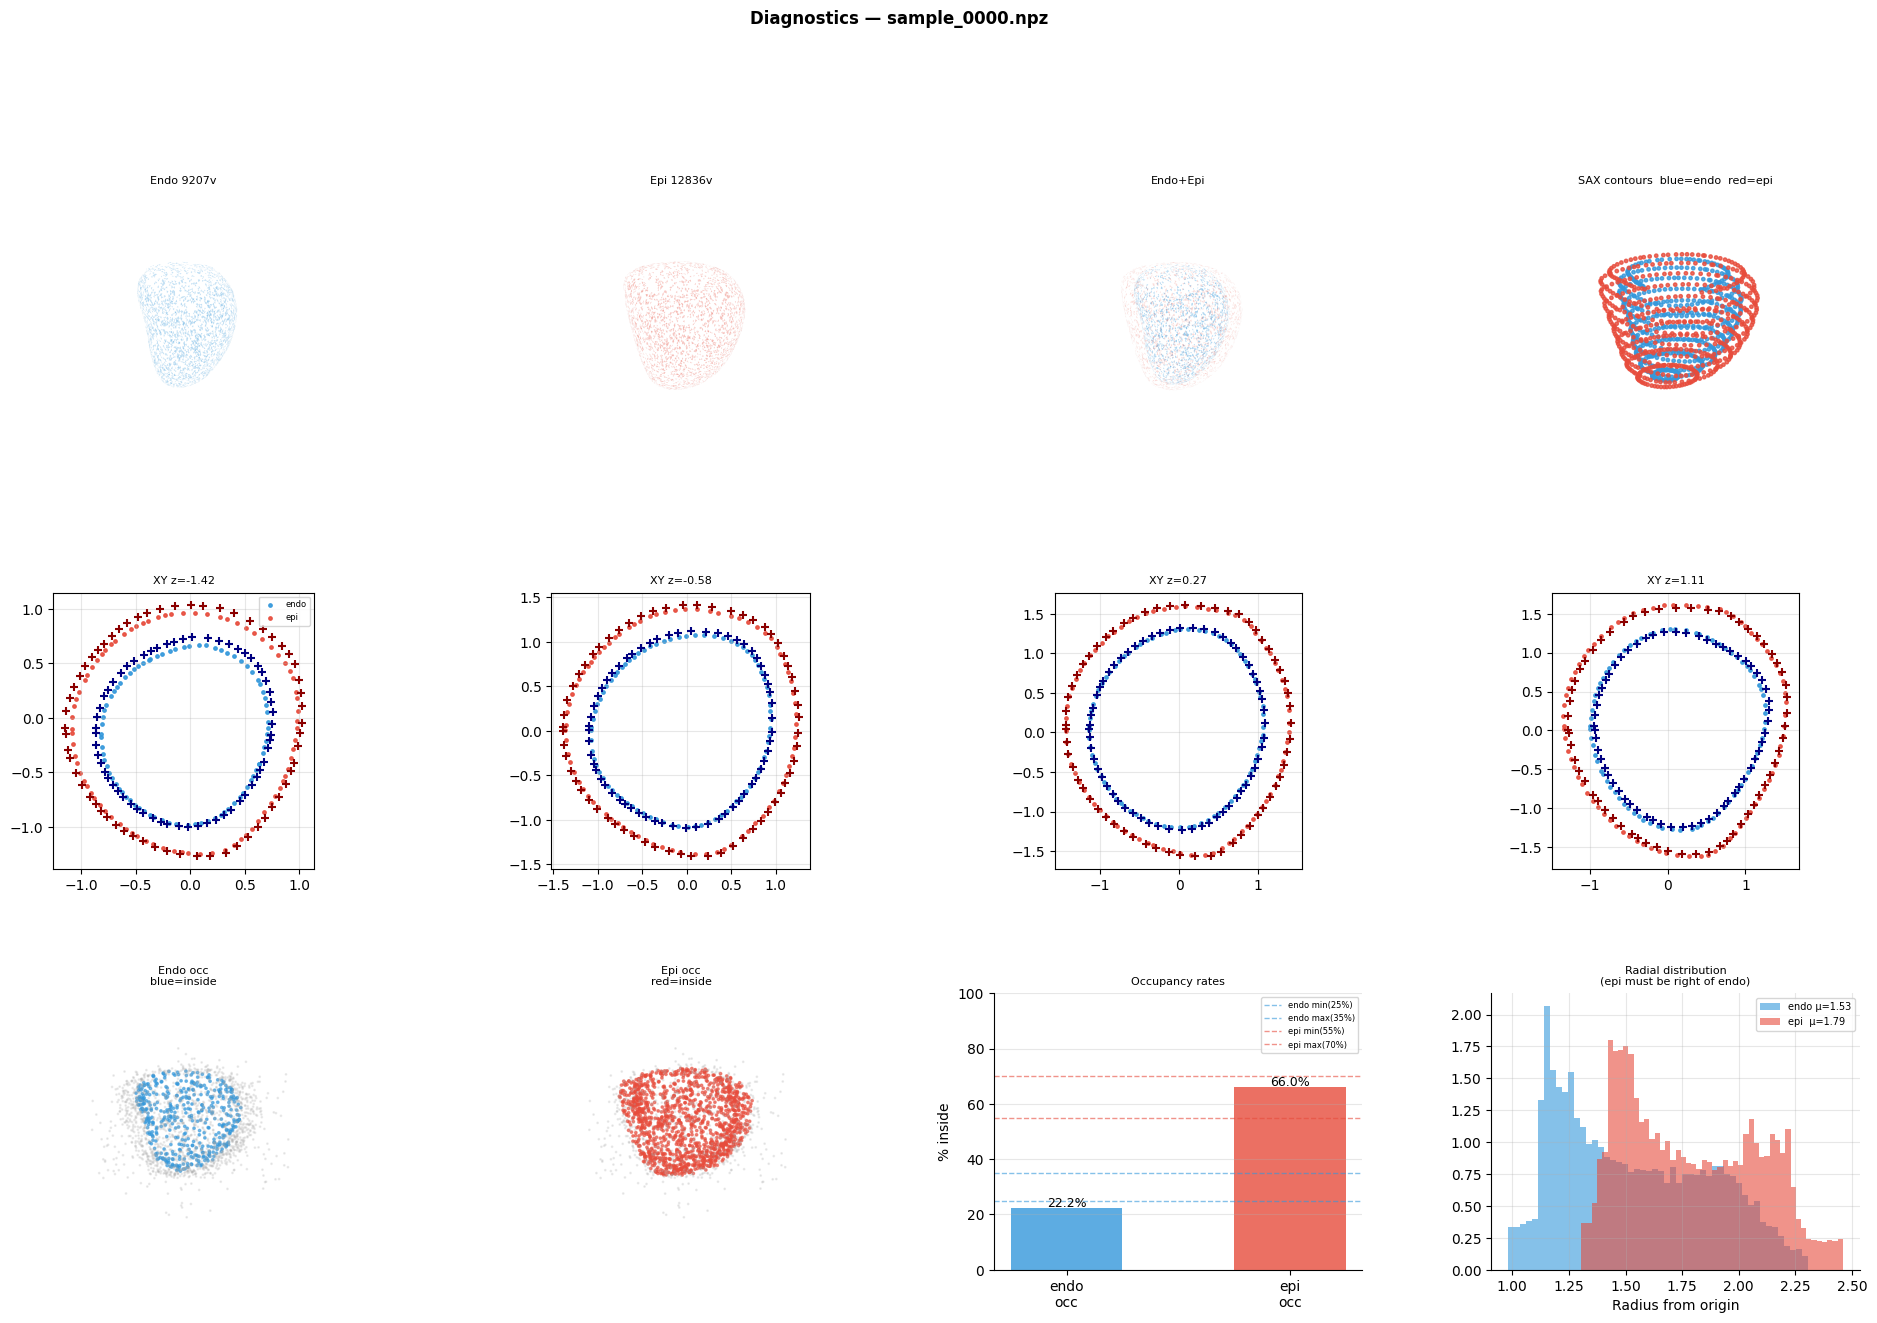

Saved: /kaggle/working/occupancy_cache/sample_0000_diag.png


In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection


def plot_sample_diagnostics(sample_path):
    d = np.load(sample_path)
    endo_v = d['endo_vertices'];  endo_f = d['endo_faces']
    epi_v  = d['epi_vertices'];   epi_f  = d['epi_faces']
    contour= d['contour']
    query  = d['query']
    endo_occ = d['endo_occ'];  epi_occ = d['epi_occ']
    xyz = contour[:,:3];  tissue = contour[:,3]

    fig = plt.figure(figsize=(24,14))
    gs  = plt.GridSpec(3, 4, figure=fig, hspace=0.45, wspace=0.35)

    # ── Row 0: 3-D mesh views ────────────────────────────────────
    def draw_mesh(ax, vv, ff, color, title):
        ridx = np.random.choice(len(ff), min(3000,len(ff)), replace=False)
        ax.add_collection3d(Poly3DCollection(vv[ff[ridx]],
                            alpha=0.3, facecolor=color, edgecolor='none'))
        c=vv.mean(0); h=(vv.max(0)-vv.min(0)).max()/2+0.05
        ax.set(xlim=(c[0]-h,c[0]+h),ylim=(c[1]-h,c[1]+h),zlim=(c[2]-h,c[2]+h))
        ax.set_axis_off(); ax.view_init(20,45); ax.set_title(title,fontsize=8)

    draw_mesh(fig.add_subplot(gs[0,0],projection='3d'),endo_v,endo_f,'#3498db',
              f'Endo {len(endo_v)}v')
    draw_mesh(fig.add_subplot(gs[0,1],projection='3d'),epi_v,epi_f,'#e74c3c',
              f'Epi {len(epi_v)}v')

    ax=fig.add_subplot(gs[0,2],projection='3d')
    for vv,ff,col,a in[(endo_v,endo_f,'#3498db',0.4),(epi_v,epi_f,'#e74c3c',0.2)]:
        ridx=np.random.choice(len(ff),min(2000,len(ff)),replace=False)
        ax.add_collection3d(Poly3DCollection(vv[ff[ridx]],alpha=a,facecolor=col,edgecolor='none'))
    av=np.vstack([endo_v,epi_v]); c=av.mean(0); h=(av.max(0)-av.min(0)).max()/2+0.05
    ax.set(xlim=(c[0]-h,c[0]+h),ylim=(c[1]-h,c[1]+h),zlim=(c[2]-h,c[2]+h))
    ax.set_axis_off(); ax.view_init(20,45); ax.set_title('Endo+Epi',fontsize=8)

    ax=fig.add_subplot(gs[0,3],projection='3d')
    ax.scatter(*xyz[tissue==0].T,c='#3498db',s=6,alpha=0.8)
    ax.scatter(*xyz[tissue==1].T,c='#e74c3c',s=6,alpha=0.8)
    ax.set_axis_off(); ax.view_init(20,30)
    ax.set_title('SAX contours  blue=endo  red=epi',fontsize=8)

    # ── Row 1: XY cross-sections ─────────────────────────────────
    # Use slice_mesh_at_z directly — same function that built the cache.
    # Result: exactly 2 rings per slice (one endo, one epi).
    z_vals = np.linspace(endo_v[:,2].min(), endo_v[:,2].max(), 6)[1:-1]
    for col, zc in enumerate(z_vals):
        ax = fig.add_subplot(gs[1, col])

        for vv, ff, color, label in [(endo_v, endo_f, '#3498db', 'endo'),
                                      (epi_v,  epi_f,  '#e74c3c', 'epi')]:
            ring = slice_mesh_at_z(vv, ff, float(zc), pts_per_ring=80)
            if ring is not None:
                ax.scatter(ring[:,0], ring[:,1], s=6, c=color,
                           label=label, alpha=0.9)

        # Cross-mark the cached contour points at this z
        # (should land exactly on the rings above)
        nearest_si = np.argmin(np.abs(d['slice_z'] - zc))  # zc is already normalised
        sc = d['slice_ids'] == nearest_si
        if sc.sum() > 0:
            ax.scatter(xyz[sc&(tissue==0),0], xyz[sc&(tissue==0),1],
                       s=30, c='navy',   marker='+', zorder=5)
            ax.scatter(xyz[sc&(tissue==1),0], xyz[sc&(tissue==1),1],
                       s=30, c='darkred',marker='+', zorder=5)

        ax.set_title(f'XY z={zc:.2f}', fontsize=8)
        ax.set_aspect('equal'); ax.grid(alpha=0.3)
        if col == 0: ax.legend(fontsize=6)

    # ── Row 2: occupancy diagnostics ─────────────────────────────
    for c2, (occ, color, title) in enumerate([
            (endo_occ,'#3498db','Endo occ\nblue=inside'),
            (epi_occ, '#e74c3c','Epi occ\nred=inside')]):
        ax=fig.add_subplot(gs[2,c2],projection='3d')
        ins = occ==1
        ax.scatter(*query[ins].T,  c=color,   s=3, alpha=0.6)
        ax.scatter(*query[~ins].T, c='#aaaaaa',s=1, alpha=0.2)
        ax.set_axis_off(); ax.view_init(20,45); ax.set_title(title,fontsize=8)

    ax=fig.add_subplot(gs[2,2])
    bars=ax.bar(['endo\nocc','epi\nocc'],
                [endo_occ.mean()*100,epi_occ.mean()*100],
                color=['#3498db','#e74c3c'],alpha=0.8,width=0.5)
    for ref,col2,lbl in[(25,'#3498db','endo min'),(35,'#3498db','endo max'),
                         (55,'#e74c3c','epi min'), (70,'#e74c3c','epi max')]:
        ax.axhline(ref,color=col2,ls='--',lw=1,alpha=0.6,label=f'{lbl}({ref}%)')
    for bar in bars:
        ax.text(bar.get_x()+bar.get_width()/2,bar.get_height()+0.5,
                f'{bar.get_height():.1f}%',ha='center',fontsize=9)
    ax.set_ylim(0,100); ax.set_ylabel('% inside')
    ax.set_title('Occupancy rates',fontsize=8)
    ax.legend(fontsize=6); ax.grid(alpha=0.3,axis='y')
    ax.spines[['top','right']].set_visible(False)

    # Radial separation sanity check — epi peak must be right of endo
    ax=fig.add_subplot(gs[2,3])
    r_e=np.linalg.norm(endo_v,axis=1); r_p=np.linalg.norm(epi_v,axis=1)
    ax.hist(r_e,bins=50,alpha=0.6,color='#3498db',
            label=f'endo μ={r_e.mean():.2f}',density=True)
    ax.hist(r_p,bins=50,alpha=0.6,color='#e74c3c',
            label=f'epi  μ={r_p.mean():.2f}',density=True)
    ax.set_xlabel('Radius from origin')
    ax.set_title('Radial distribution\n(epi must be right of endo)',fontsize=8)
    ax.legend(fontsize=7); ax.grid(alpha=0.3)
    ax.spines[['top','right']].set_visible(False)

    fig.suptitle(f'Diagnostics — {Path(sample_path).name}',
                 fontsize=12,fontweight='bold',y=1.01)
    out=str(sample_path).replace('.npz','_diag.png')
    plt.savefig(out,dpi=150,bbox_inches='tight',facecolor='white')
    plt.show()
    print(f'Saved: {out}')


for f in sorted(Path(CFG['cache_dir']).glob('sample_*.npz')):
    plot_sample_diagnostics(f)


## 10. Summary

In [ ]:
sample_files = sorted(cache_dir.glob('sample_*.npz'))
total = sum(f.stat().st_size for f in sample_files)
print(f'Files: {len(sample_files)}')
print(f'Total: {total/1024**2:.1f} MB  Avg: {total/max(len(sample_files),1)/1024:.1f} KB')
with open(cache_dir/'split.json') as f:
    sp=json.load(f)
print(f'Train={len(sp["tr"])}  Val={len(sp["val"])}  Test={len(sp["te"])}')


## 11. Next steps

**Upload as Kaggle dataset:**
1. Output panel → **New Dataset** → `lv-occupancy-cache`

**Training notebook:**
```python
CFG['cache_dir'] = '/kaggle/input/lv-occupancy-cache/occupancy_cache'

with open(f'{CFG["cache_dir"]}/split.json') as f:
    split = json.load(f)

# Dataloader
d = np.load(f"{CFG['cache_dir']}/sample_{idx:04d}.npz")

# SlicePointNetEncoder
contour   = torch.from_numpy(d['contour'])        # (N, 4)  xyz + tissue
slice_ids = torch.from_numpy(d['slice_ids'])       # (N,)    group by slice

# CrossSliceTransformer + SliceQueryConditioner
slice_z      = torch.from_numpy(d['slice_z'])       # (n_slices,)
slice_z_mask = torch.from_numpy(d['slice_z_mask'])  # (n_slices,) attention mask

# FourierPE + SliceCondINRDecoder
query    = torch.from_numpy(d['query'])             # (2048, 3)
endo_occ = torch.from_numpy(d['endo_occ'])          # (2048,)  supervision
epi_occ  = torch.from_numpy(d['epi_occ'])           # (2048,)  supervision
```
